# Практическая работа №3. Свёрточные нейронные сети







Работу выполнил (а): Нгуен Кхань Нгок - 345148

# Классификация цветов с помощью свёрточных нейронных сетей.

В работе необходимо познакомится с различными архитектурами сверхточных нейронных сетей и их обучением на GPU (англ. graphics processing, графический процессор) на языке программирования Python 3 и фреймворка Torch (PyTorch). Для этого предлагается использовать ресурсы Google Colab - Colaboratory, для выполнения вычислений на GPU. После с ознакомления, выполнить практическое задане в конце данной тетради (notebook).

Рассмотрим Датасет содержащий 4242 изображения цветов размеченных по 5 видам (тюльпан, ромашка, подсолнух, роза, одуванчик). Данный набор данных можно скачать по ссылке с сайте kaggle.

Загрузите папку с картинками на гугл диск, чтобы не загружать ее каждый раз заново при перезапуске колаба. Структура файлов (можно посмотреть в меню слева) может быть такой: "/content/drive/My Drive/data/flowers".

Обязательно подключите аппаратный ускоритель (GPU) к среде выполнения. В меню сверху: Среда выполнения -> Сменить среду выполнения

Первым делом разберите более детально код выполнив код ниже.

# Подготовка

Загружаем библиотеки. Фиксируем random.seed для воспроизводимости

In [25]:
import numpy as np
import os
import torch
import torchvision
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

random.seed(0)
torch.manual_seed(0)

Выбираем на чем будем делать вычисления - CPU или GPU (cuda)

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


Блок для соединения с Google Colab

In [27]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
FOLDERNAME = '/content/drive/MyDrive/Colab Notebooks/AI COURSE 2024/LAB3/flowers'

assert FOLDERNAME is not None, "[!] Enter the foldername."

%cd /content/drive/MyDrive/
#%cp -r $FOLDERNAME ../../
#%cd ../../
%cd Colab\ Notebooks/AI\ COURSE\ 2024/LAB3/flowers
#!bash get_datasets.sh
#%cd ../../

#+For kaggle______________________________________________
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# FOLDERNAME = '/kaggle/input/flowers-recognition/flowers'
# %cd /kaggle/input/flowers-recognition/flowers

Обучение предобученной сверточной архитектуры для задач классификации цветов


In [28]:
# Выберите модель из списка доступных в PyTorch моделей
# Не забудьте указать, что она модель должна быть предобучена!
# Написать свой код здесь...
model = torchvision.models.resnet50(pretrained=True)

# RESNET50

## Описание RESNET50

**Resnet50**- это нервная сеть с глубиной 50 слоев. Эта модель обучена более чем 1 миллионам изображений из базы данных ImageNet. Он может классифицировать до 1000 объектов, а сеть, обученная цветным изображениям 224 × 224 пикселей.

- Архитектура ResNet50 организована в Residual Block. Он предназначен для решения проблемы vanishing gradient в глубоких сетях, а также для повышения производительности в задачах распознавания больших изображений, таких как ImageNet.

  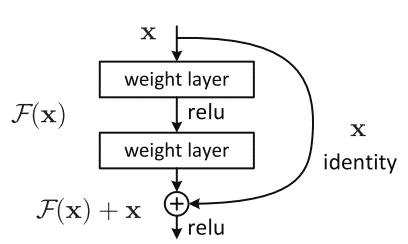

**Vanishing gradient**
Это проблема при обучении многослойных нейронных сетей. При обучении значения производной - это обратная связь процесса обратного распространения. Это значение становится чрезвычайно небольшим в первых нейронных слоях, что обновление веса сети не может произойти.

## Архитектура Resnet50
### ResNet50 architecture

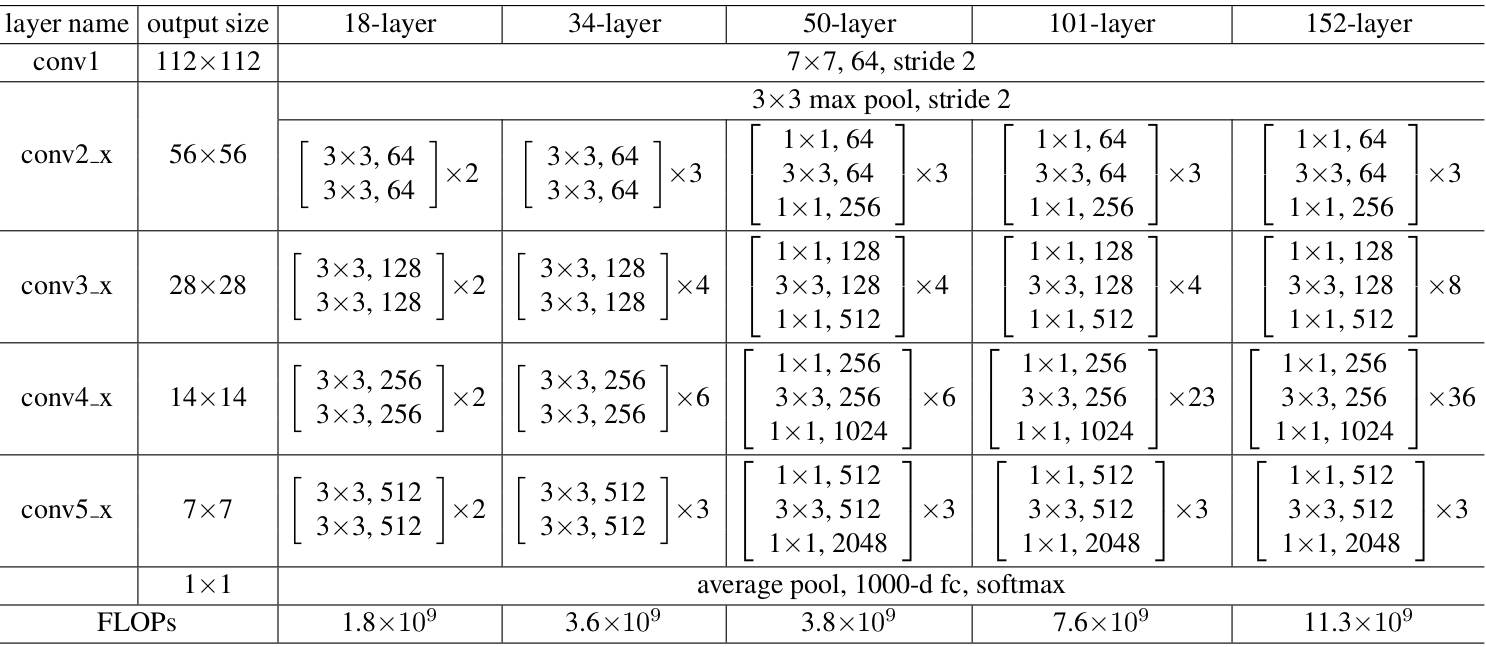

На рисунке мы видим, что архитектура Resnet 50 содержит следующий элемент:
- Своялка с размер ядра 7 * 7 и 64 различных ядер, все с размером шага 2, что дает нам **1 слой**.

- Затем мы видим максимальное слияние с размером шага 2.
- Следующая свертка имеет 1x1, 64 ядра, за которым следует ядро ​​3 * 3,64 и, наконец, 1x1, 256 ядра. Эти три слоя повторяются в общей сложности 3 раза, давая нам **9 слоев** на этом этапе.
- Затем мы видим Core 1x1, 128, затем Core 3x3, 128 и, наконец, Core 1x1, 512, этот шаг был повторен 4 раза, давая нам **12 слоев** на этом этапе.

- После этого есть ядро ​​1x1, 256 и еще два ядра с 3x3, 256 и 1x1, 1024, и это повторяется 6 раз, что дает нам в общей сложности **18 слоев**.
- А затем снова 1x1, 512 ядра с еще двумя 3x3, 512 и 1x1, 2048 ядра, и это повторяется 3 раза, что дает нам в общей сложности **9 слоев**.
- После этого мы делаем средний бассейн и завершаем его полностью подключенным слоем, содержащим 1000 узлов и функцию Softmax на конце, так что это дает нам **1 слой.**
- Мы на самом деле не учитываем функции активации и макс/среднее объединение слоев.
- Таким образом, это дает нам 1 + 9 + 12 + 18 + 9 + 1 = 50 слоев глубокой сверточной сети.

## Neural Network и Fully connected neural network
### Convolutional Neural Network:

* Архитектуры CNN делают явное предположение, что входы являются изображениями, что позволяет кодировать определенные свойства в архитектуре модели.
* Простой CNN - это последовательность слоев, и каждый слой CNN преобразует одно количество активаций в другую, используя дифференцируемую функцию. Три основных типа слоев используются для построения архитектуры CNN: сверточный слой, слияние и полностью подключенный слой.

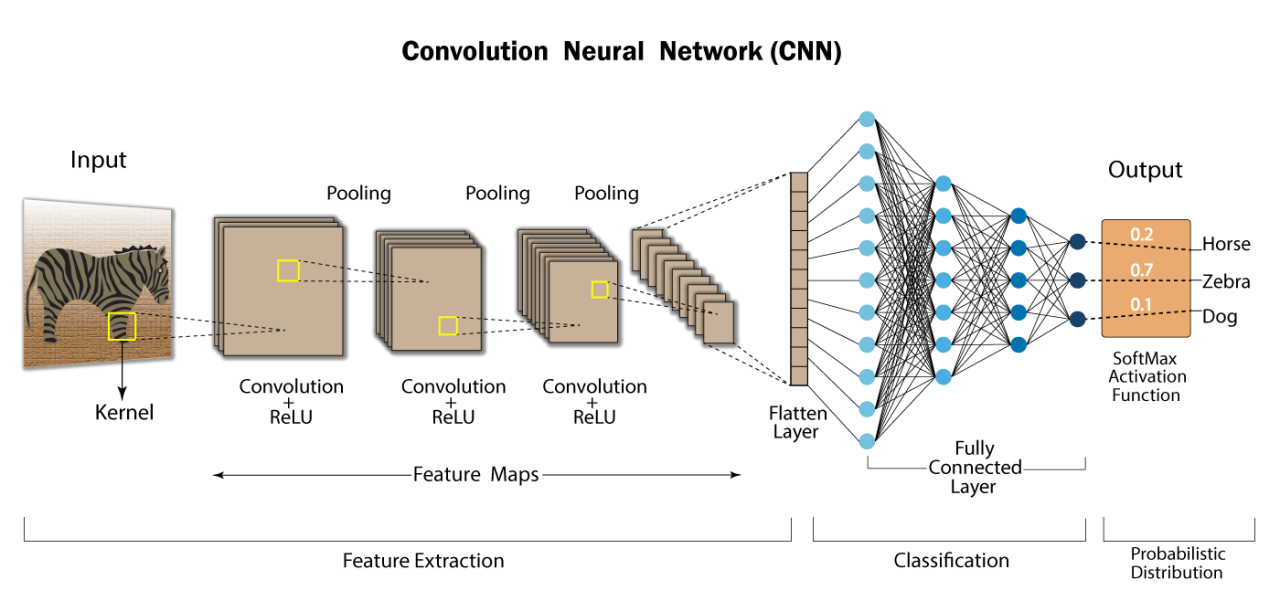

### Fully connected neural network

- Fully connected neural network состоит из ряда полностью подключенных слоев, которые соединяют каждый нейрон в один слой к каждому нейрону в другом слое.
Основным преимуществом полностью подключенных сетей является то, что они «независимы от структуры», то есть нет необходимости делать какие -либо особые предположения о входных данных.

- Несмотря на то, что независимые от структуры делают все возможное, чтобы сети полной связи очень широко применимы, такие сети, как правило, имеют более низкую производительность, чем специальные сети, настроенные на структуру проблемного пространства.

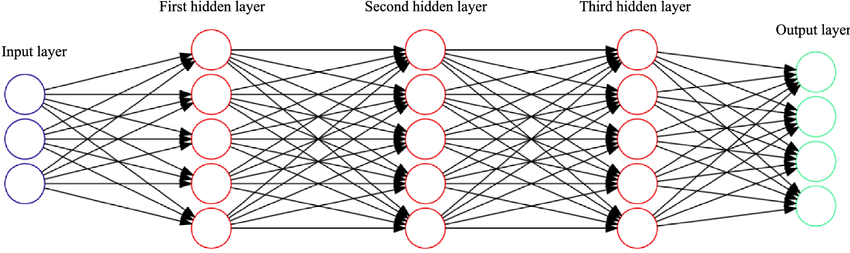

# Convolutional Neural Network (CNN)

- Существует три типа слоев, которые составляют CNN, которые являются сверточными слоями (convolutional), pooling слоями и fully-connected (FC) слоями. Когда эти слои сложены, будет сформирована архитектура CNN.

## Convolutional layers
- Этот слой является первым слоем, который используется для извлечения различных функций из входных изображений. В этом слое выполняется операция математической свертки между входным изображением и фильтром определенного размера M x M. При перемещении фильтра по входному изображению, скалярное продукт принимается между фильтром и частями входного изображения относительно размера фильтра (M x M).



![](https://ars.els-cdn.com/content/image/3-s2.0-B9780128190616000069-f06-06-9780128190616.jpg)


## Pooling Layer
- Максимальное объединение или максимальное объединение - это операция объединения, которая вычисляет максимальное или наибольшее значение в каждом участке каждой карты объектов.

  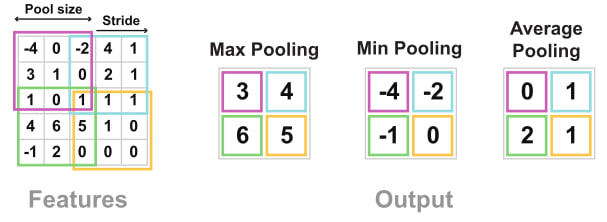

## Fully Connected Layer
- Fully Connected (FC) слой состоит из весов и смещений вместе с нейронами и используется для соединения нейронов между двумя разными слоями. Эти слои обычно помещаются перед выходным слоем и образуют последние несколько слоев архитектуры CNN.

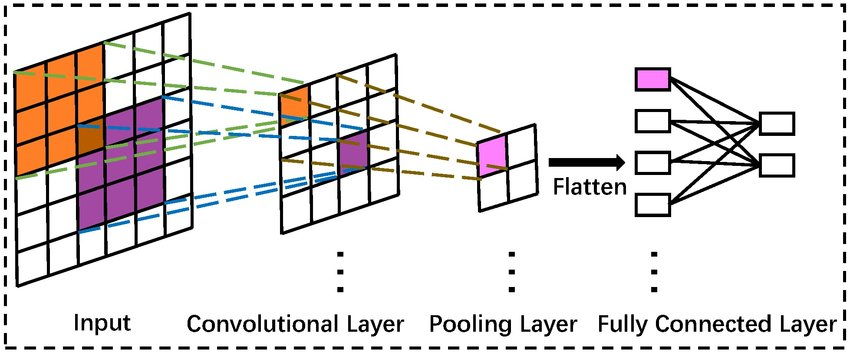

Подготавливаем набор данных, классы распределяем по папкам

In [29]:
prepare_imgs = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((224, 224)), #приводим картинки к одному размеру
        torchvision.transforms.ToTensor(), # упаковывем их в тензор
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] # нормализуем картинки по каналам
        ),
    ]
)
# задаем датасет. Лейблы - имена папок:
dataset = ImageFolder('/content/drive/MyDrive/Colab Notebooks/AI COURSE 2024/LAB3/flowers', transform=prepare_imgs)

In [30]:
dataset.imgs[2]

('/content/drive/MyDrive/Colab Notebooks/AI COURSE 2024/LAB3/flowers/daisy/10172379554_b296050f82_n.jpg',
 0)

# Заморозка весов модели

## Слои и модели имеют три атрибута веса:
- Веса - это список всех весовых переменных в слое.
- Trainable_weights* - это список тех, которые должны быть обновлены (через gradient descent), чтобы минимизировать потери во время обучения.
- non_trainable_weights* - это список тех, которые не предназначены для обучения. Они обычно обновляются моделью во время прямого прохода.

## Заморозка весов модели
- это процесс, при котором веса (параметры) определённых слоёв модели остаются неизменными во время обучения. Другими словами, слои с замороженными весами не участвуют в процессе обратного распространения ошибки и их параметры не обновляются gradient descent.

In [31]:
# Функция для заморозки весов модели
def set_parameter_requires_grad(model):
  for param in model.parameters():
    param.requires_grad = False

set_parameter_requires_grad(model)

**Изменить последнее fully connected в параметрах модели**

In [32]:
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 5)
)

In [33]:
# Проверим все ли сработало правильно, выведем веса, которые будут обучаться
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.0.weight
fc.0.bias
fc.2.weight
fc.2.bias
fc.4.weight
fc.4.bias


# Задаем параметры и функцию для обучения. Разбиваем датасет на train/validation

**Utilities**

Обычно используется для обозначения наборов функций, классов или инструментов поддержки, созданных для выполнения общих или повторяющихся задач в программировании.

In [34]:
class ValueMeter(object):
  """
  Вспомогательный класс, чтобы отслеживать loss и метрику
  """
  def __init__(self):
      self.sum = 0
      self.total = 0

  def add(self, value, n):
      self.sum += value*n
      self.total += n

  def value(self):
      return self.sum/self.total

def log(mode, epoch, loss_meter, accuracy_meter, best_perf=None):
  """
  Вспомогательная функция, чтобы
  """
  print(
      f"[{mode}] Epoch: {epoch:0.2f}. "
      f"Loss: {loss_meter.value():.2f}. "
      f"Accuracy: {100*accuracy_meter.value():.2f}% ", end="\n")

  if best_perf:
      print(f"[best: {best_perf:0.2f}]%", end="")


**Set dataloaders**

Разбиваем датасет на train и validation

Задаем dataloader'ы - объекты для итеративной загрузки данных и лейблов для обучения и валидации

In [35]:
batch_size = 32

train_set, val_set = torch.utils.data.random_split(dataset, [len(dataset)-1000, 1000])
print('The size of the training and validation dataset: ', len(train_set), len(val_set))
loaders = {'training': DataLoader(train_set, batch_size, pin_memory=True,num_workers=2, shuffle=True),
           'validation':DataLoader(val_set, batch_size, pin_memory=True,num_workers=2, shuffle=False)}

The size of the training and validation dataset:  3337 1000


**Optimizer and metrics**

In [45]:
optimizer = torch.optim.Adam(params = model.parameters())
lr = 0.001

**Функция для подсчета Accuracy**


In [37]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

**Функция для обучения и валидации модели**

In [38]:
def trainval(model, loaders, optimizer, epochs=10):
    """
    model: модель, которую собираемся обучать
    loaders: dict с dataloader'ами для обучения и валидации
    """
    loss_meter = {'training': ValueMeter(), 'validation': ValueMeter()}
    accuracy_meter = {'training': ValueMeter(), 'validation': ValueMeter()}

    loss_track = {'training': [], 'validation': []}
    accuracy_track = {'training': [], 'validation': []}

    for epoch in range(epochs): # итерации по эпохам
        for mode in ['training', 'validation']: # обучение - валидация
            # считаем градиаент только при обучении:
            with torch.set_grad_enabled(mode == 'training'):
                # в зависимоти от фазы переводим модель в нужный ружим:
                model.train() if mode == 'training' else model.eval()
                for imgs, labels in tqdm(loaders[mode]):
                    imgs = imgs.to(device) # отправляем тензор на GPU
                    labels = labels.to(device)
                    bs = labels.shape[0]  # размер батча (отличается для последнего батча в лоадере)

                    preds = model(imgs) # forward pass - прогоняем тензор с картинками через модель
                    loss = F.cross_entropy(preds, labels) # считаем функцию потерь
                    acc = accuracy(preds, labels) # считаем метрику

                    # храним loss и accuracy для батча
                    loss_meter[mode].add(loss.item(), bs)
                    accuracy_meter[mode].add(acc, bs)

                    # если мы в фазе обучения
                    if mode == 'training':
                        optimizer.zero_grad() # обнуляем прошлый градиент
                        loss.backward() # делаем backward pass (считаем градиент)
                        optimizer.step() # обновляем веса
            # в конце фазы выводим значения loss и accuracy
            log(mode, epoch, loss_meter[mode], accuracy_meter[mode])

            # сохраняем результаты по всем эпохам
            loss_track[mode].append(loss_meter[mode].value())
            accuracy_track[mode].append(accuracy_meter[mode].value())
    return loss_track, accuracy_track

**Функция сохранения информации о модели**

In [39]:
WEIGHTS_PATH = '/content/drive/MyDrive/Colab Notebooks/AI COURSE 2024/LAB3/WEIGHTS.pth'

CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/AI COURSE 2024/LAB3/CP_MODEL.pt'


def save_weights(weights_fname, model):
  torch.save(model.state_dict(), weights_fname)

def save_checkpoint(checkpoint_path, model, epoch, optimizer, loss):
  torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            }, checkpoint_path)

**Модель обучения**

In [40]:
model.to(device) # Отправляем модель на GPU
optimizer = optimizer # алгоритм оптимизации
loss_track, accuracy_track = trainval(model, loaders, optimizer, epochs=10) #обратить внимание на loss_track и accuracy_track

100%|██████████| 105/105 [00:25<00:00,  4.11it/s]


[training] Epoch: 0.00. Loss: 0.64. Accuracy: 76.90% 


100%|██████████| 32/32 [00:06<00:00,  4.62it/s]


[validation] Epoch: 0.00. Loss: 0.37. Accuracy: 86.20% 


100%|██████████| 105/105 [00:21<00:00,  4.87it/s]


...

[validation] Epoch: 8.00. Loss: 0.34. Accuracy: 88.28% 


100%|██████████| 105/105 [00:22<00:00,  4.68it/s]


[training] Epoch: 9.00. Loss: 0.33. Accuracy: 88.00% 


100%|██████████| 32/32 [00:05<00:00,  5.43it/s]

[validation] Epoch: 9.00. Loss: 0.33. Accuracy: 88.55% 


# Оценить модель

In [41]:
save_weights(WEIGHTS_PATH, model)

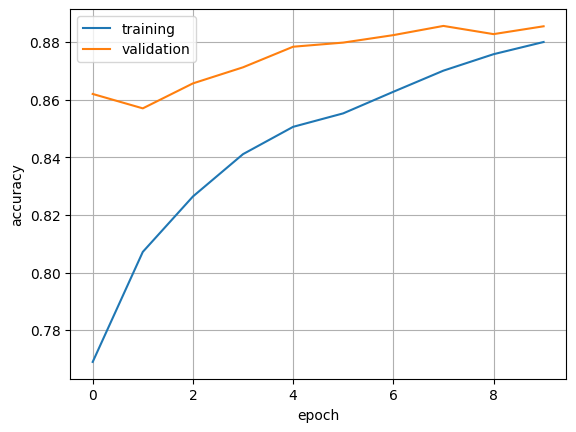

In [42]:
plt.plot(accuracy_track['training'], label='training')
plt.plot(accuracy_track['validation'], label='validation')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.grid()
plt.legend()
plt.show()

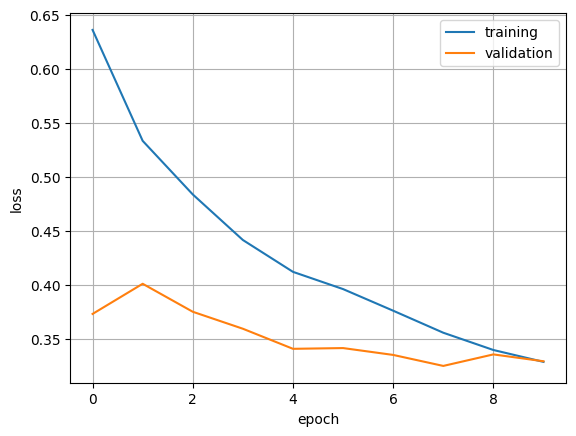

In [43]:
plt.plot(loss_track['training'], label='training')
plt.plot(loss_track['validation'], label='validation')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.grid()
plt.legend()
plt.show()

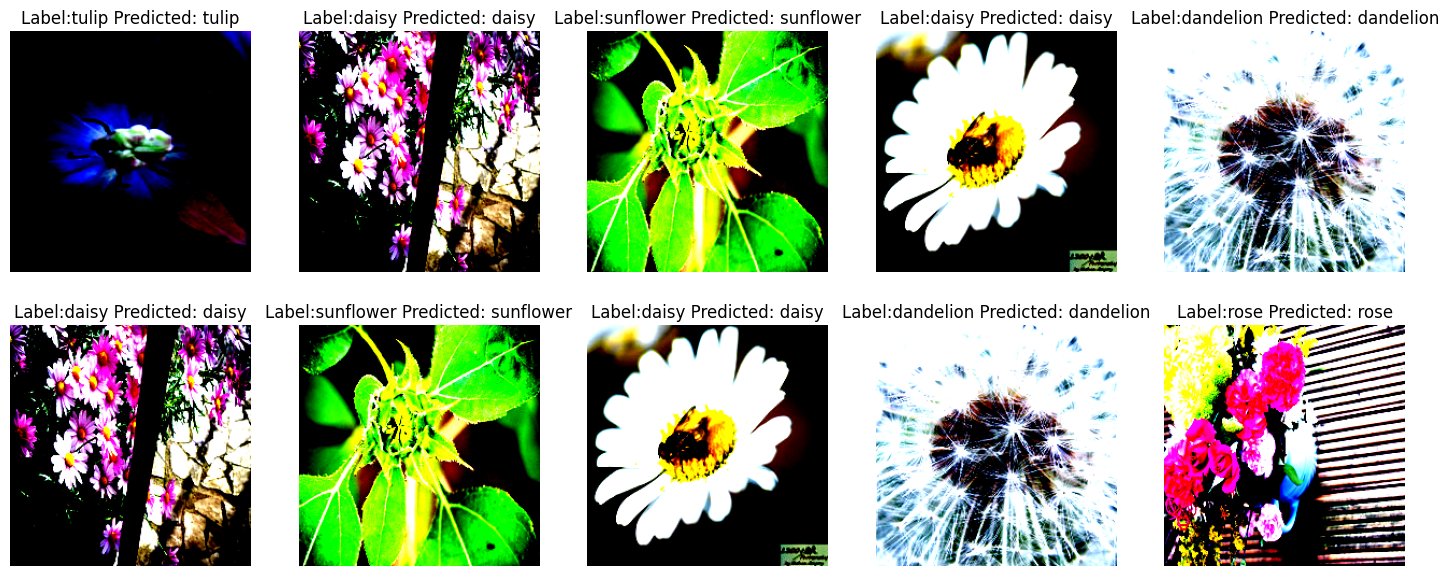

In [44]:
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

def predict_image(img, model):
    xb = img.unsqueeze(0).to(device)
    yb = model(xb)
    _, preds  = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]

fig, axs = plt.subplots(2,5, figsize=(18,7))
for i in range(2):
  for j in range(5):
    img, label = val_set[i+j]
    axs[i,j].imshow(img.clip(0,1).permute(1, 2, 0))
    axs[i,j].axis('off')
    label = dataset.classes[label]
    pred = predict_image(img, model)
    title = 'Label:' + label+' Predicted: '+ pred
    axs[i,j].set_title(title)
plt.show()

# Вопросы

**1. В чем основные отличия между сверточной нейронной сетью и "обычной" полносвязной нейронной сетью?**
- Полностью связанный слой относится к нейронной сети, в которой каждый входной узел соединен с каждым выходным узлом. В сверточном слое не все узлы соединены

**2. Что такое transfer learning? Что такое предобученная нейронная сеть?**
- **Transfer learning** — это метод машинного обучения, в котором уже обученная на одной задаче модель используется в качестве основы для другой задачи.
- **Предобученная нейронная сеть** - это модель, которая уже была обучена на большом и разнообразном наборе данных

**3. Как работает блок "Сверточная нейросеть с нуля"? Описать сверточный и пулинговый слой.**

- Блок модели в коде состоит из сверточных слоев, функций активации, пулинговых слоев и полносвязных слоев.
- **Сверточный слой** (Convolutional Layer)
  - Использует ядро (filter/kernel) — небольшой матричный фильтр, который "скользит" по изображению (матрице пикселей).
  - Для каждого положения ядра вычисляется свертка: скалярное произведение ядра и соответствующей области изображения.

```
nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
```
  - Вход: изображение RGB (33 канала).
  - Выход: 32 карт признаков.
  - Размер ядра: 3×3, шаг 1, отступ 1.

- **Pooling Layer**
  - Уменьшает размер карты признаков, "сжимая" информацию.
  - Обрабатывает области изображения независимыми блоками и извлекает ключевые значения.


```
nn.MaxPool2d(kernel_size=2, stride=2)

```

  - Размер блока: 2×2.
  - Шаг: 2.

1. **Первый блок:**
```
nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.MaxPool2d(2, 2)
```
- Вход: изображение 32×32×3
- Первые два сверточных слоя: создают 64 карт признаков
- Max Pooling: уменьшает размер до 16x16x64


2. **Второй блок**
```
nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.MaxPool2d(2, 2)
```
- Сверточные слои создают 128 карт признаков
- Max Pooling: уменьшает размер до 8x8x128

3. **Третий блок**
```
nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
nn.ReLU()
nn.MaxPool2d(2, 2)
```
- Сверточные слои создают 256 карт признаков (8×8×256).
- Max Pooling: уменьшает размер до 4x4x256

4. **Полносвязные слои**
```
nn.Flatten(),
nn.Linear(256*4*4, 1024),
nn.ReLU(),
nn.Linear(1024, 512),
nn.ReLU(),
nn.Linear(512, 5)
```
- Уплощение выходного тензора 4x4x256 = 4096
- Преобразования: 4096 -> 1024 -> 512 -> 5